<a href="https://colab.research.google.com/github/Rizkyard17/Geospatial-House-Price-Analysis-and-Regression-Modeling/blob/main/Predict_Pakistan_House_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Business Understanding

Harga properti dipengaruhi oleh banyak faktor seperti lokasi, luas bangunan, jumlah kamar, dan jenis properti. Project ini bertujuan membangun model machine learning berbasis linear regression dari scratch untuk memprediksi harga properti di Pakistan serta mengidentifikasi faktor-faktor yang paling mempengaruhi harga properti.

# Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns
import numpy as np
from google.colab import drive
from IPython.display import Markdown, display

# Import Dataset

Dataset diperoleh dari kaggle: https://www.kaggle.com/datasets/sarcasmos/pakistan-house-prices-and-property-listings

In [2]:
# Drive Connect
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
path = '/content/drive/MyDrive/Dataset/Pakistan House Prices and Property Listings.csv'
df = pd.read_csv(path)
print("Dataste berhasil dimuat")

Dataste berhasil dimuat


# Data Understanding

## Cek Tipe Data

In [4]:
# cek variabel data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    168446 non-null  int64  
 1   location_id    168446 non-null  int64  
 2   page_url       168446 non-null  object 
 3   property_type  168446 non-null  object 
 4   price          168446 non-null  int64  
 5   location       168446 non-null  object 
 6   city           168446 non-null  object 
 7   province_name  168446 non-null  object 
 8   latitude       168446 non-null  float64
 9   longitude      168446 non-null  float64
 10  baths          168446 non-null  int64  
 11  area           168446 non-null  object 
 12  purpose        168446 non-null  object 
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  object 
 15  agency         124375 non-null  object 
 16  agent          124374 non-null  object 
dtypes: float64(2), int64(5), obje

In [5]:
df.head()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,4 Marla,For Sale,2,2/4/2019,NaN,NaN
1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,5.6 Marla,For Sale,3,5/4/2019,NaN,NaN
2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,8 Marla,For Sale,5,7/17/2019,NaN,NaN
3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,2 Kanal,For Sale,4,4/5/2019,NaN,NaN
4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,8 Marla,For Sale,3,7/10/2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director


Dataset memiliki 17 variabel (kolom) dengan 168446 baris (rows), diantaranya:

*   **property_id** (int64) : ID unik properti
*   **location_id** (int64) : ID Lokasi
*   **page_url** (object) : url halaman properti
*   **property_type** (object) : Jenis Properti (kategorikal)
*   **price** (int64) : Harga Properti (Rupee Pakistan)
*   **location** (object) : Nama Lokasi
*   **city** (object) : Nama Kota
*   **province_name** (object) : Nama Provinsi
*   **latitude** (float64) : Garis Lintang
*   **longitude** (float64) : Garis Bujur
*   **baths** (int64) : Jumlah Kamar Mandi
*   **area** (object) : Luas Property
*   **purpose** (object) : Tujuan (sale atau rent)
*   **bedrooms** (int64) : Jumlah Kamar Tidur
*   **date_added** (object) : Tanggal Properti ditambahkan
*   **agency** (object) : Nama Agensi Properti
*   **agent** (object) : Nama Agen Properti











## Penyesuaian Tipe Data

In [6]:
# ubah kolom date_added menjadi bentuk datetime
df['date_added'] = pd.to_datetime(df['date_added'])

satuan dalam kolom 'areas' mengikuti satuan di negara pakistan (contoh: 4 marla, 2 kanal, dll). Oleh karena itu, akan dikonversi menjadi satuan persegi agar mudah dimengerti.

1 marla = 272.25 sqft
1 kanal = 20 marla
1 sq ft = 1 sq ft

In [7]:
# Fungsi konversi ke square feet
def convert_area_to_sqft(area_str):
    if pd.isna(area_str):
        return None

    area_str = str(area_str).lower().strip()

    # Ekstrak angka dan satuan
    match = re.search(r'([\d\.]+)\s*(\w+)', area_str)
    if not match:
        return None

    value = float(match.group(1))
    unit = match.group(2)

    # Konversi berdasarkan satuan
    if unit in ['marla', 'marla']:
        return value * 272.25
    elif unit in ['kanal']:
        return value * 5445
    elif unit in ['sqft', 'sq ft', 'square feet', 'sq.ft']:
        return value
    elif unit in ['sqyd', 'sq yd', 'square yard', 'yard']:
        return value * 9
    else:
        return None  # satuan tidak dikenal

In [8]:
# Ubah kolom areas menjadi satuan persegi
df['area_sqft'] = df['area'].apply(convert_area_to_sqft)
print(df[['area', 'area_sqft']].head(10))

        area  area_sqft
0    4 Marla    1089.00
1  5.6 Marla    1524.60
2    8 Marla    2178.00
3    2 Kanal   10890.00
4    8 Marla    2178.00
5  1.6 Kanal    8712.00
6    1 Kanal    5445.00
7  6.2 Marla    1687.95
8    1 Kanal    5445.00
9    1 Kanal    5445.00


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   property_id    168446 non-null  int64         
 1   location_id    168446 non-null  int64         
 2   page_url       168446 non-null  object        
 3   property_type  168446 non-null  object        
 4   price          168446 non-null  int64         
 5   location       168446 non-null  object        
 6   city           168446 non-null  object        
 7   province_name  168446 non-null  object        
 8   latitude       168446 non-null  float64       
 9   longitude      168446 non-null  float64       
 10  baths          168446 non-null  int64         
 11  area           168446 non-null  object        
 12  purpose        168446 non-null  object        
 13  bedrooms       168446 non-null  int64         
 14  date_added     168446 non-null  datetime64[ns]
 15  

In [10]:
# Drop kolom yang tidak penting
df.drop(columns=['area', 'agency', 'agent'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   property_id    168446 non-null  int64         
 1   location_id    168446 non-null  int64         
 2   page_url       168446 non-null  object        
 3   property_type  168446 non-null  object        
 4   price          168446 non-null  int64         
 5   location       168446 non-null  object        
 6   city           168446 non-null  object        
 7   province_name  168446 non-null  object        
 8   latitude       168446 non-null  float64       
 9   longitude      168446 non-null  float64       
 10  baths          168446 non-null  int64         
 11  purpose        168446 non-null  object        
 12  bedrooms       168446 non-null  int64         
 13  date_added     168446 non-null  datetime64[ns]
 14  area_sqft      168446 non-null  float64       
dtype

## Cek Missing Value

In [11]:
# Cek Missing Value
df.isna().sum()

,0
property_id,0
location_id,0
page_url,0
property_type,0
price,0
location,0
city,0
province_name,0
latitude,0
longitude,0


## Cek Duplikasi Data

In [12]:
# Cek Duplikasi Data
print("jumlah redudansi data: ",df.duplicated().sum())

jumlah redudansi data:  0


## Cek Kategori Properti

### Berdasarkan Kota

In [13]:
# Cek berapa jumlah kategori kota
df.value_counts(df['city'])

,count
city,
Karachi,60484
Lahore,41427
Islamabad,37426
Rawalpindi,20976
Faisalabad,8133


Berdasarkan data yang digunakan, jumlah kategori kota dalam data adalah:


1.   Karachi : 60484
2.   Lahore : 41427
3.   Islamabad : 37426
4.   Rawalpindi : 20976
5.   Faisalabad : 8133

Dalam data, kota yang mendominasi adalah Karachi dengan jumlah sebesar 60484

### Berdasarkan Provinsi

In [14]:
# Cek berapa jumlah kategori provinsi
df.value_counts(df['province_name'])

,count
province_name,
Punjab,70536
Sindh,60484
Islamabad Capital,37426


Pada bagian provinsi, urutan yang diperoleh adalah sebagai berikut:


1.   Punjab : 70536
2.   Sindh : 60484
3.   Islamabad Capital : 37426

Berikut adalah banyak kota dalam setiap provinsi:

* Punjab (Lahore, Rawalpindi, Faisalabad)
* Sindh (Karachi)
* Islamabad Capital (Islamabad)

Secara jumlah, provinsi Punjab menjadi yang paling banyak, namun perlu disadari bahwa hasil tersebut diperoleh dari 3 kota yang berbeda. Sedangkan jumlah pada provinsi Sindh dan provinsi Islamabad Capital hanya diperoleh dari 1 kota saja. Sehingga secara rasio, provinsi sindh menjadi yang paling banyak property yang dijual.

### Berdasarkan Harga

In [15]:
# Cek berapa jumlah kategori harga
df.value_counts(df['price'])

,count
price,
15000000,2589
35000,2522
6500000,2415
8500000,2154
12500000,2117
...,...
560000000,1
607500000,1
620000000,1


Dari hasil tersebut, diperoleh bahwa harga yang paling banyak ditetapkan/dipatok oleh penjual property adalah sebesar 15000000, dengan total jumlah 2589 property diharga yang sama.  

### Berdasarkan Purpose

In [16]:
# Cek berapa jumlah kategori purpose
df.value_counts(df['purpose'])

,count
purpose,
For Sale,120655
For Rent,47791


Terdapat 120655 properti yang mau dijual. Sedangkan 47791 properti yang mau disewakan.

# Exploratory Data Analysis (EDA)

## Penjualan vs Penyewaan (Sale vs Rent)

/tmp/ipykernel_7243/1697669613.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=purpose_counts.index, y=purpose_counts.values, ax=ax1, palette='viridis')


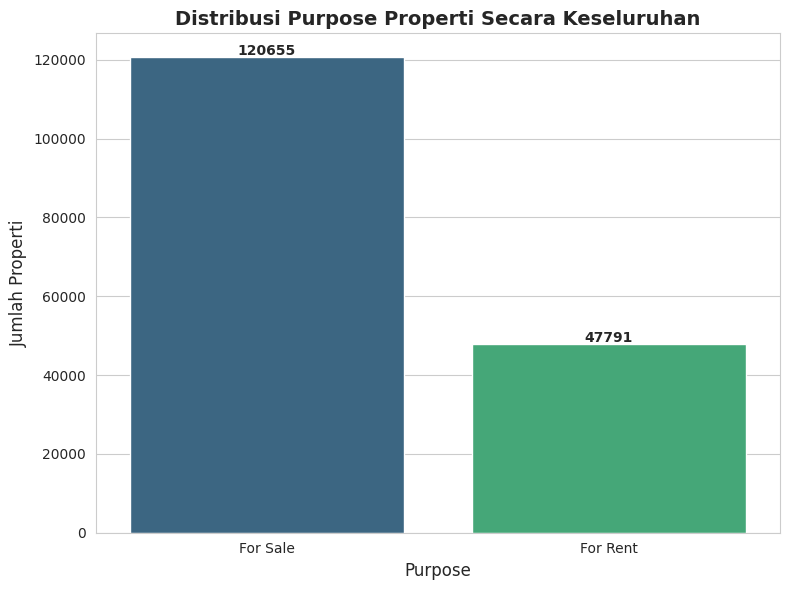

In [17]:
sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (12, 6)



# GRAFIK KESELURUHAN
fig1, ax1 = plt.subplots(figsize=(8, 6))

purpose_counts = df['purpose'].value_counts()

sns.barplot(x=purpose_counts.index, y=purpose_counts.values, ax=ax1, palette='viridis')

ax1.set_title('Distribusi Purpose Properti Secara Keseluruhan', fontsize=14, fontweight='bold')

ax1.set_xlabel('Purpose', fontsize=12)

ax1.set_ylabel('Jumlah Properti', fontsize=12)



# Tambahkan angka di atas batang
for i, v in enumerate(purpose_counts.values):

    ax1.text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.tight_layout()

plt.show()

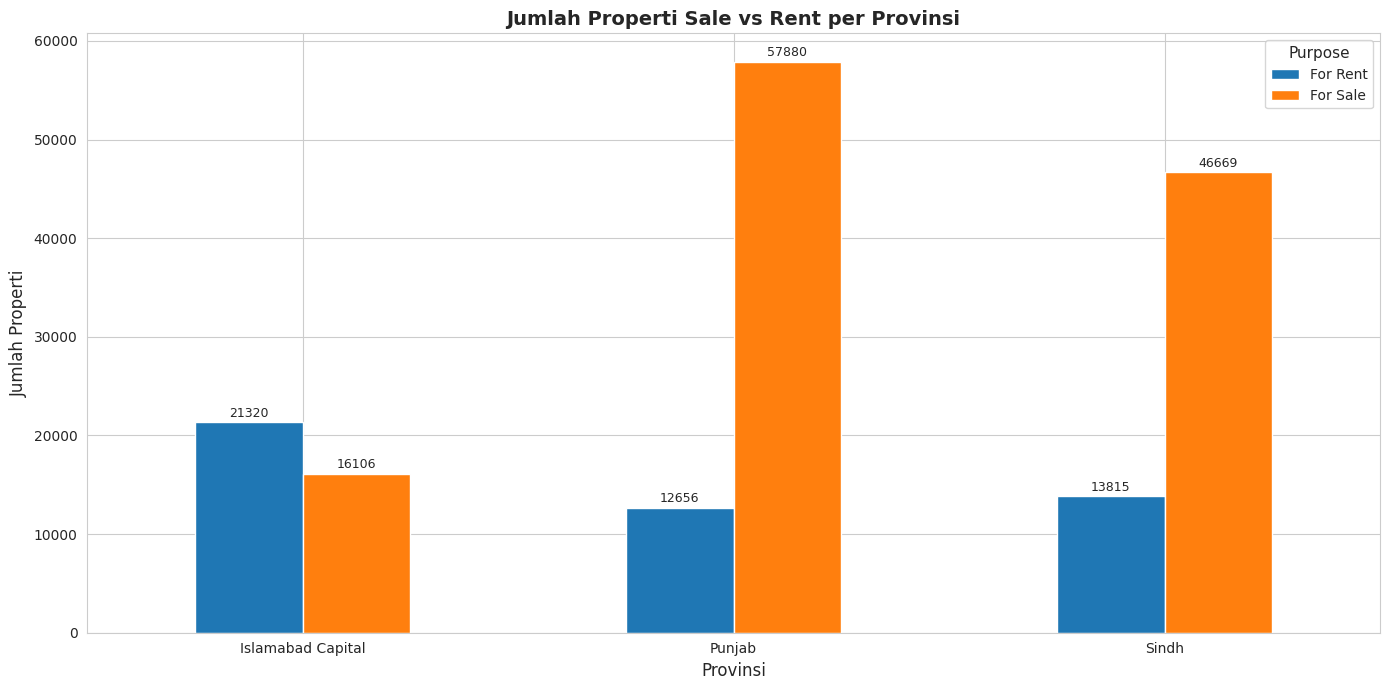

In [18]:
# GRAFIK PER PROVINSI (Groupby Province)

# Hitung jumlah per provinsi dan purpose
province_purpose = pd.crosstab(df['province_name'], df['purpose'])



# Plot stacked bar chart (lebih baik untuk perbandingan proporsi)
fig2, ax2 = plt.subplots(figsize=(14, 7))

province_purpose.plot(kind='bar', stacked=False, ax=ax2, color=['#1f77b4', '#ff7f0e'])

ax2.set_title('Jumlah Properti Sale vs Rent per Provinsi', fontsize=14, fontweight='bold')

ax2.set_xlabel('Provinsi', fontsize=12)

ax2.set_ylabel('Jumlah Properti', fontsize=12)

ax2.legend(title='Purpose', title_fontsize=11)

ax2.tick_params(axis='x', rotation=0)



# Tambahkan label nilai di atas batang
for container in ax2.containers:

    ax2.bar_label(container, fmt='%d', fontsize=9, padding=2)

plt.tight_layout()

plt.show()

Hasil dari grafik tersebut diketahui bahwa:
1. Pada provinsi Islamabad Capital, diperoleh bahwa lebih banyak properti yang disewakan yaitu sebanyak 21320 property. Sedangkan yang dijual hanya 16106 property.
2. Pada provinsi punjab, diperoleh bahwa property yang dijual sangat mendominasi dibandingkan dengan property yang disewakan. Property yang dijual berjumlah 57880, sedangkan yang disewakan sebanyak 12656.
3. Pada provinsi Sindh, diperoleh bahwa property yang dijual juga mendominasi dibandingkan property yang disewakan yaitu sebanyak 46669, sedangkan yang disewakan hanya 13815.

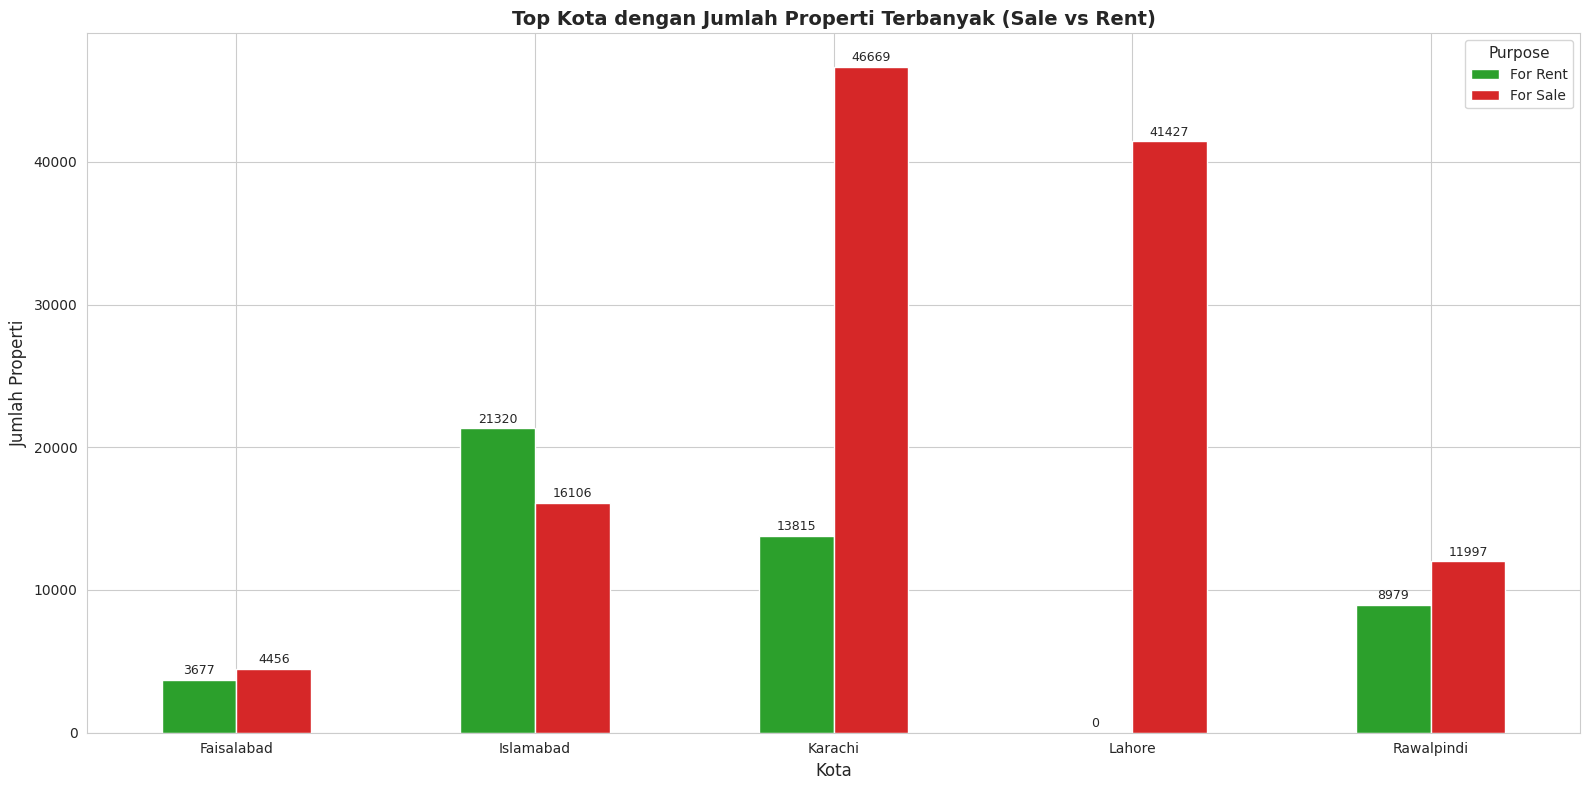

In [19]:
# GRAFIK PER KOTA
city_purpose = pd.crosstab(df['city'], df['purpose'])

fig3, ax3 = plt.subplots(figsize=(16, 8))

city_purpose.plot(kind='bar', stacked=False, ax=ax3, color=['#2ca02c', '#d62728'])

ax3.set_title('Top Kota dengan Jumlah Properti Terbanyak (Sale vs Rent)', fontsize=14, fontweight='bold')

ax3.set_xlabel('Kota', fontsize=12)

ax3.set_ylabel('Jumlah Properti', fontsize=12)

ax3.legend(title='Purpose', title_fontsize=11)

ax3.tick_params(axis='x', rotation=0)


# Tambahkan label nilai di atas batang
for container in ax3.containers:

    ax3.bar_label(container, fmt='%d', fontsize=9, padding=2)

plt.tight_layout()

plt.show()

Hasil dari grafik tersebut diketahui bahwa:
1. Pada kota Faisalabad, diperoleh bahwa sebanyak 4456 property dijual dan 3677 property disewakan.
2. Pada kota islamabad, diperoleh bahwa sebanyak 16106 property dijual dan 21320 property disewakan.
3. Pada kota Karachi, diperoleh bahwa sebanyak 46669 property dijual dan 13815 property disewakan.
4. Pada kota Lahore, diperoleh bahwa sebanyak 41427 property dijual dan 0 property disewakan.
5. Pada kota Rawalpindi, diperoleh bahwa sebanyak 11997 property dijual dan 8979 property disewakan.

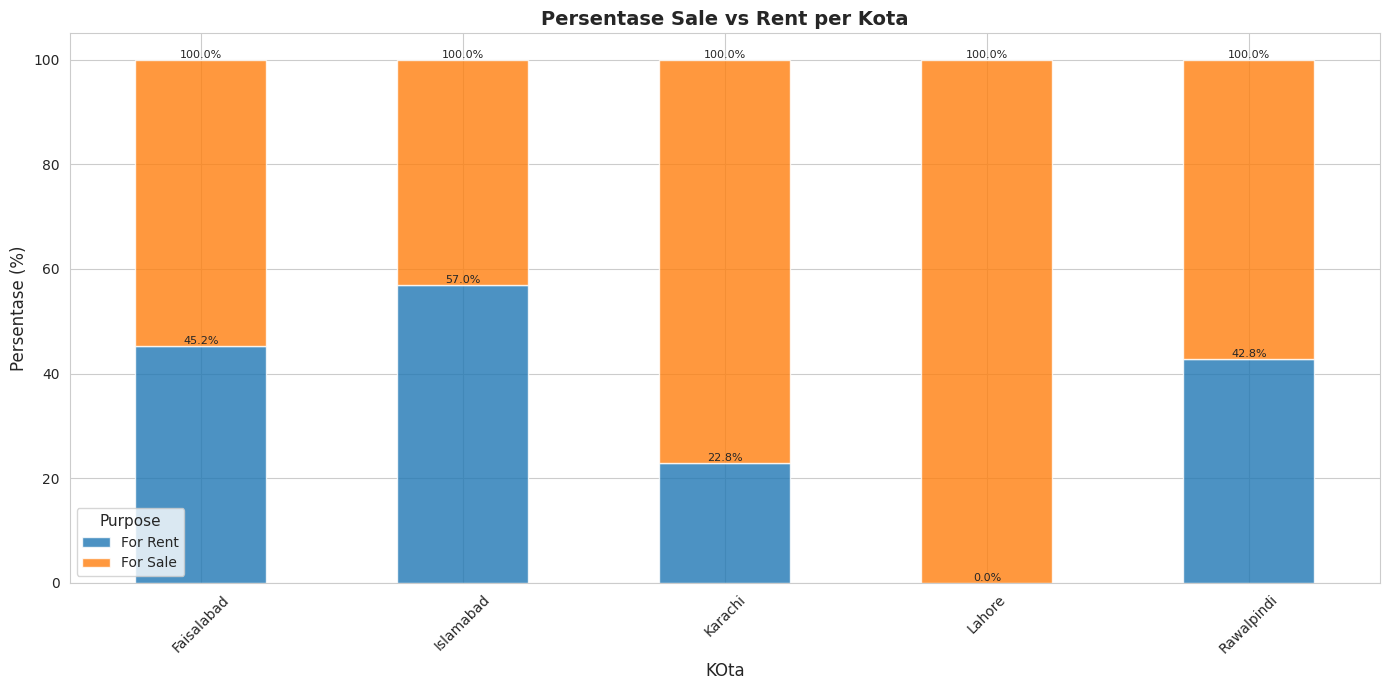

In [20]:
# Grafik Persentase per kota
# Untuk melihat proporsi dalam persen
city_pct = city_purpose.div(city_purpose.sum(axis=1), axis=0) * 100

fig4, ax4 = plt.subplots(figsize=(14, 7))

city_pct.plot(kind='bar', stacked=True, ax=ax4, color=['#1f77b4', '#ff7f0e'], alpha=0.8)



ax4.set_title('Persentase Sale vs Rent per Kota', fontsize=14, fontweight='bold')

ax4.set_xlabel('KOta', fontsize=12)

ax4.set_ylabel('Persentase (%)', fontsize=12)

ax4.legend(title='Purpose', title_fontsize=11)

ax4.tick_params(axis='x', rotation=45)



# Tambahkan label persentase pada batang
for container in ax4.containers:

    ax4.bar_label(container, fmt='%.1f%%', fontsize=8)

plt.tight_layout()

plt.show()

### Insight Analisis Purpose: Sale vs Rent

## 1. Perbandingan Antar Provinsi

Berdasarkan data yang diperoleh, provinsi Punjab memiliki jumlah properti tertinggi secara absolut yaitu sebanyak 70.536 properti. Namun, angka ini berasal dari 3 kota berbeda (Lahore, Rawalpindi, Faisalabad). Sementara itu, provinsi Sindh dan Islamabad Capital masing-masing hanya diwakili oleh satu kota, yaitu Karachi (60.484 properti) dan Islamabad (37.426 properti).

Jika dihitung rata-rata per kota, Sindh justru menjadi provinsi dengan kepadatan properti tertinggi, yaitu 60.484 properti per kota, disusul oleh Islamabad dengan 37.426 properti per kota, dan Punjab hanya 23.512 properti per kota.

**Kesimpulan:** Karachi adalah pasar properti terpadat dan paling aktif di Pakistan secara per kota, meskipun total propertinya berada di urutan kedua.

---

## 2. Proporsi Sale vs Rent per Provinsi

Dari sisi tujuan properti, ditemukan perbedaan yang sangat mencolok antar provinsi:

| Provinsi | Sale | Rent | Dominasi |
|----------|------|------|-----------|
| Punjab | 57.880 (82%) | 12.656 (18%) | Sale sangat dominan |
| Sindh | 46.669 (77%) | 13.815 (23%) | Sale dominan |
| Islamabad Capital | 16.106 (43%) | 21.320 (57%) | Rent lebih dominan |

**Insight utama:** Islamabad adalah satu-satunya wilayah di mana properti sewa (Rent) justru lebih banyak dibandingkan properti yang dijual (Sale). Hal ini berbeda dengan Punjab dan Sindh yang didominasi oleh transaksi jual beli.

**Rekomendasi bisnis:**
- Jika fokus pada penjualan properti, targetkan pasar di Punjab dan Sindh.
- Jika fokus pada bisnis penyewaan, Islamabad adalah pasar yang paling potensial.

---

## 3. Distribusi per Kota

Ketika diurai per kota, ditemukan pola yang lebih detail:

| Kota | Sale | Rent | Provinsi |
|------|------|------|----------|
| Lahore | 41.427 | 0 | Punjab |
| Karachi | 46.669 | 13.815 | Sindh |
| Islamabad | 16.106 | 21.320 | Islamabad |
| Rawalpindi | 11.997 | 8.979 | Punjab |
| Faisalabad | 4.456 | 3.677 | Punjab |

**Temuan penting:** Kota Lahore mencatatkan angka 0 untuk properti sewa. Ini sangat tidak wajar mengingat Lahore adalah kota metropolitan terbesar di Punjab.

**Rekomendasi:** Lakukan validasi ulang terhadap data mentah untuk kota Lahore sebelum mengambil keputusan bisnis di wilayah tersebut.

---

## 4. Perbandingan Kota dalam Satu Provinsi (Punjab)

Di provinsi Punjab, ketiga kotanya menunjukkan karakteristik yang berbeda:

- **Rawalpindi:** Sale 11.997 vs Rent 8.979 → cenderung seimbang, sedikit condong ke Sale.
- **Faisalabad:** Sale 4.456 vs Rent 3.677 → hampir seimbang.
- **Lahore:** Data tidak valid (0 Rent).

**Insight:** Rawalpindi dan Faisalabad dapat dijadikan benchmark yang lebih realistis untuk memahami pasar properti di Punjab. Kedua kota ini menunjukkan bahwa meskipun Sale lebih dominan, pasar sewa tetap ada dan cukup signifikan.

---

## 5. Ringkasan Strategis per Wilayah

Berikut adalah karakteristik dan potensi bisnis di setiap wilayah:

- **Karachi (Sindh):** Volume besar, dominasi Sale → cocok untuk developer dan agen properti yang fokus pada jual beli.
- **Islamabad:** Dominasi Rent → sangat cocok untuk bisnis manajemen properti sewa dan investasi berbasis sewa.
- **Rawalpindi:** Pasar dua sisi yang seimbang → fleksibel untuk berbagai model bisnis.
- **Faisalabad:** Hampir seimbang → cocok untuk diversifikasi portofolio.
- **Lahore:** Perlu validasi data ulang, jangan ambil keputusan bisnis berdasarkan data saat ini.

---

**Kesimpulan Akhir:**  
Pasar properti di Pakistan memiliki karakteristik yang sangat berbeda antar wilayah. Islamabad unik karena didominasi sewa, sementara Sindh dan Punjab didominasi jual beli. Namun, perlu diwaspadai potensi anomali data di kota Lahore yang dapat mengganggu interpretasi jika tidak ditangani dengan benar.

## Harga

/tmp/ipykernel_7243/2511177595.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


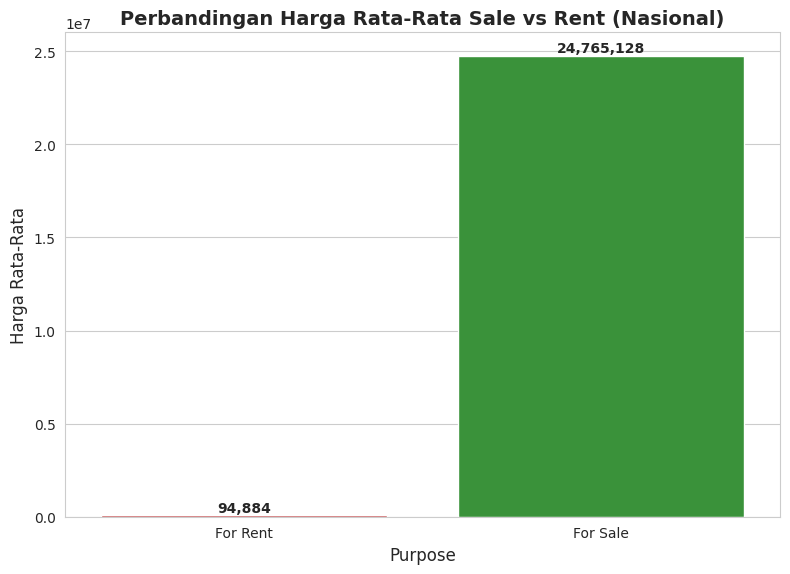

In [21]:
# Hitung harga rata-rata
mean_by_purpose = df.groupby('purpose')['price'].mean().round(0).reset_index()

# Visualisasi Data
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=mean_by_purpose,
    x='purpose',
    y='price',
    palette={'For Sale': '#2ca02c', 'For Rent': '#d62728'})

plt.title('Perbandingan Harga Rata-Rata Sale vs Rent (Nasional)', fontsize=14, fontweight='bold')

plt.xlabel('Purpose', fontsize=12)

plt.ylabel('Harga Rata-Rata', fontsize=12)



# Tambahkan label pada setiap batang
for i, (bar, value) in enumerate(zip(ax.patches, mean_by_purpose['price'])):

    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,

            f'{int(value):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')


plt.tight_layout()

plt.show()

/tmp/ipykernel_7243/518001626.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_mean_city, x = 'kota', y='Harga rata-rata', palette='viridis')


city
Lahore        25288632.0
Karachi       19838835.0
Islamabad     13398327.0
Rawalpindi     8576443.0
Faisalabad     7827574.0
Name: price, dtype: float64


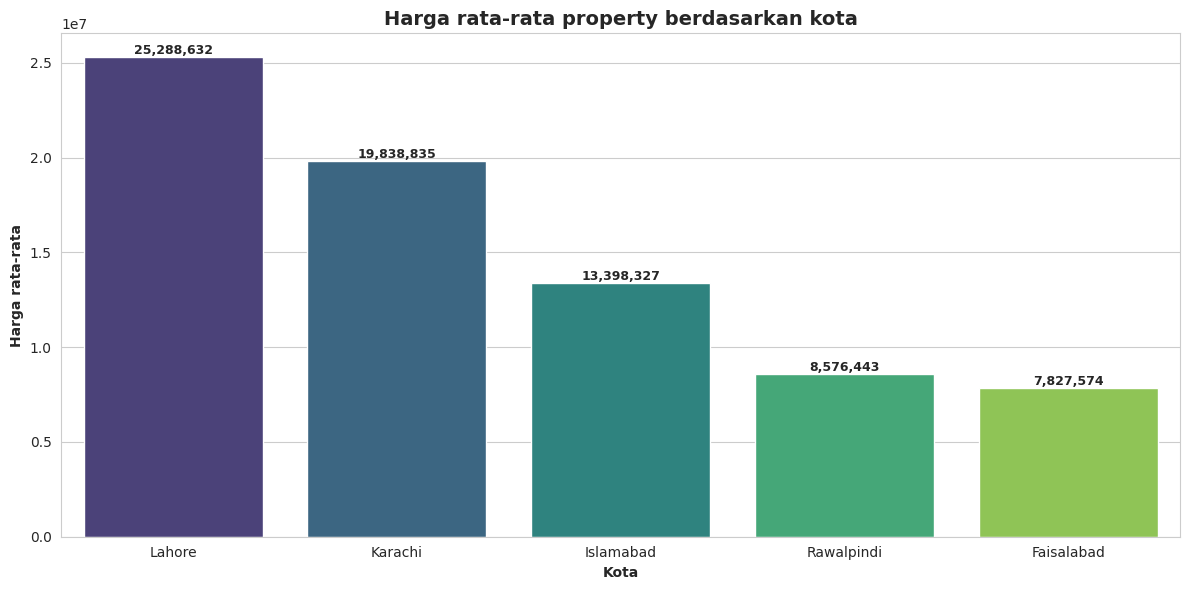

In [22]:
# Set style visualisasi
sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (12, 6)


# Hitung rata-rata per kota
harga_rata_rata_per_kota = df.groupby('city')['price'].mean().sort_values(ascending=False).round(0)

print(harga_rata_rata_per_kota)

# Jadikan Dataframe
df_mean_city = harga_rata_rata_per_kota.reset_index()

df_mean_city.columns = ['kota', 'Harga rata-rata']


#Visualisasi Data
plt.figure(figsize=(12, 6))

ax = sns.barplot(data=df_mean_city, x = 'kota', y='Harga rata-rata', palette='viridis')

plt.title("Harga rata-rata property berdasarkan kota", fontsize=14, fontweight='bold')

plt.xlabel("Kota", fontweight='bold')

plt.ylabel("Harga rata-rata", fontweight='bold')

plt.xticks(rotation=0)

# Tambahkan label pada setiap batang
for i, (bar, value) in enumerate(zip(ax.patches, df_mean_city['Harga rata-rata'])):

    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{int(value):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()

plt.show()

province_name
Sindh                19838835.0
Punjab               18305451.0
Islamabad Capital    13398327.0
Name: price, dtype: float64


/tmp/ipykernel_7243/3052708325.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_mean_province, x = 'Provinsi', y='Harga rata-rata', palette='viridis')


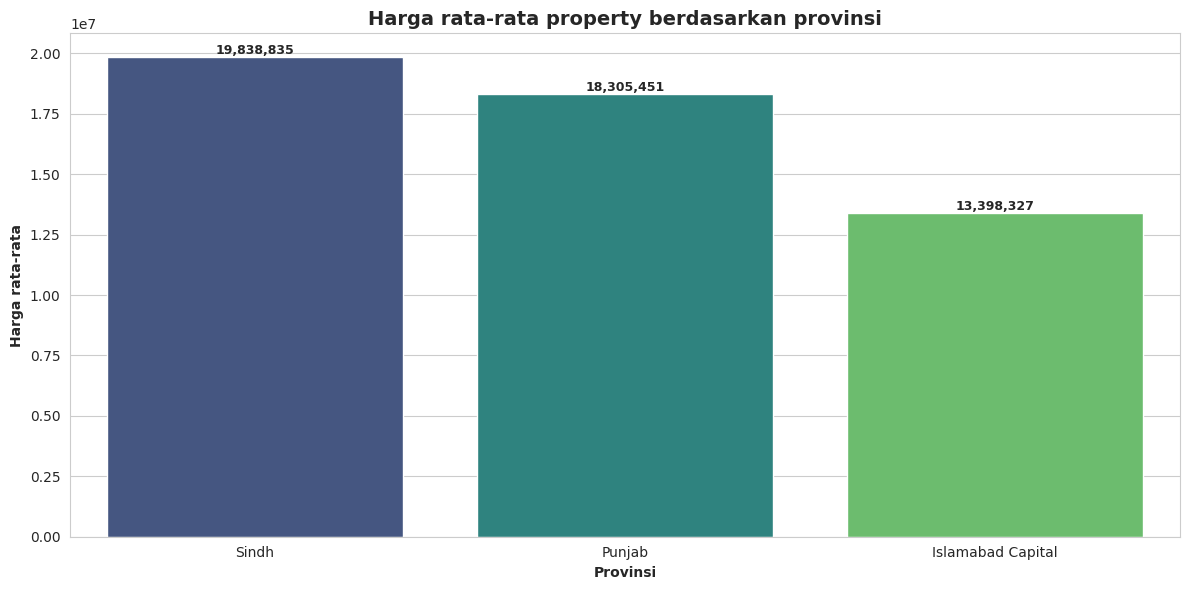

In [23]:
# Set style visualisasi
sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (12, 6)



# Hitung rata-rata per kota
harga_rata_rata_per_provinsi = df.groupby('province_name')['price'].mean().sort_values(ascending=False).round(0)

print(harga_rata_rata_per_provinsi)



# Jadikan Dataframe
df_mean_province = harga_rata_rata_per_provinsi.reset_index()

df_mean_province.columns = ['Provinsi', 'Harga rata-rata']



# Visualisasi Data
plt.figure(figsize=(12, 6))

ax = sns.barplot(data=df_mean_province, x = 'Provinsi', y='Harga rata-rata', palette='viridis')

plt.title("Harga rata-rata property berdasarkan provinsi", fontsize=14, fontweight='bold')

plt.xlabel("Provinsi", fontweight='bold')

plt.ylabel("Harga rata-rata", fontweight='bold')

plt.xticks(rotation=0)



# Tambahkan label pada setiap batang
for i, (bar, value) in enumerate(zip(ax.patches, df_mean_province['Harga rata-rata'])):

    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{int(value):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()

plt.show()

Kolom setelah pivot: ['For Rent', 'For Sale']


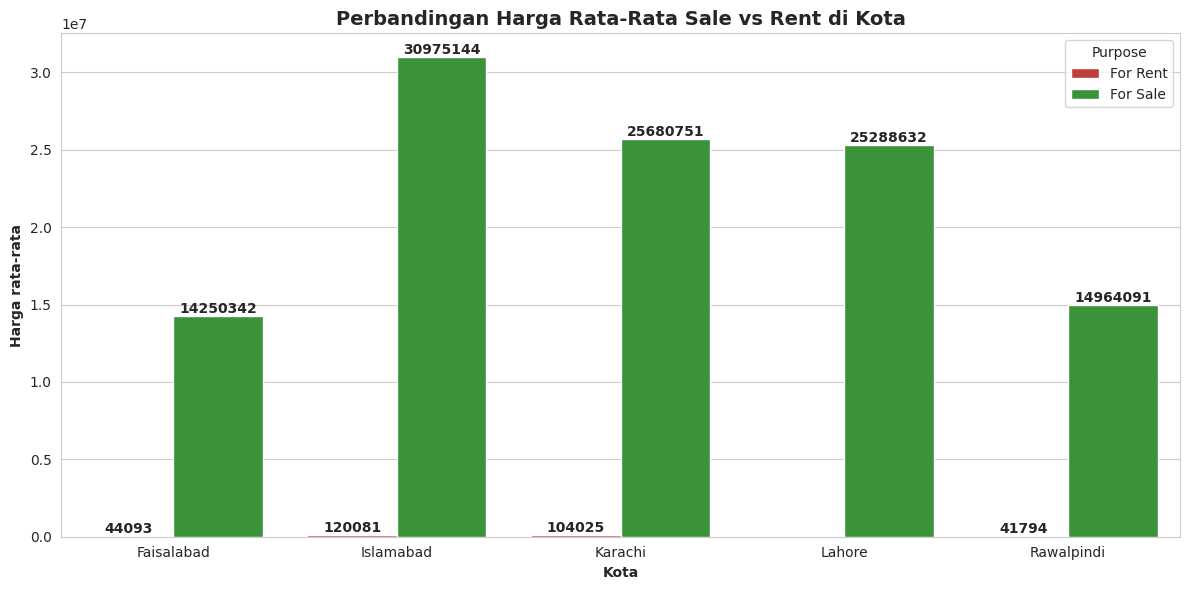

In [24]:
# hitung harga rata-rata berdasarkan kota dan purpose (sell atau rent)
harga_rata_rata_kota_purpose = df.groupby(['city', 'purpose'])['price'].mean().round(0).reset_index()

harga_rata_rata_kota_purpose.columns = ['Kota', 'Purpose', 'harga rata-rata']


# Pivot table tampilan
pivot_city_purpose = harga_rata_rata_kota_purpose.pivot(index='Kota', columns='Purpose', values='harga rata-rata').round(0)

print("Kolom setelah pivot:", pivot_city_purpose.columns.tolist())

pivot_city_purpose = pivot_city_purpose[['For Sale', 'For Rent']] # Urutkan Kolom


# Visualisasi Data
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=harga_rata_rata_kota_purpose,
    x="Kota",
    y="harga rata-rata",
    hue="Purpose",
    palette={'For Sale': '#2ca02c', 'For Rent': '#d62728'})

plt.title("Perbandingan Harga Rata-Rata Sale vs Rent di Kota", fontsize=14, fontweight='bold')

plt.xlabel("Kota", fontweight="bold")

plt.ylabel("Harga rata-rata", fontweight="bold")

plt.legend(title='Purpose')

plt.xticks(rotation=0)

for container in ax.containers:

  ax.bar_label(container, fmt='%.0f', fontsize=10, fontweight='bold')

plt.tight_layout()

plt.show()

Kolom setelah pivot: ['For Rent', 'For Sale']


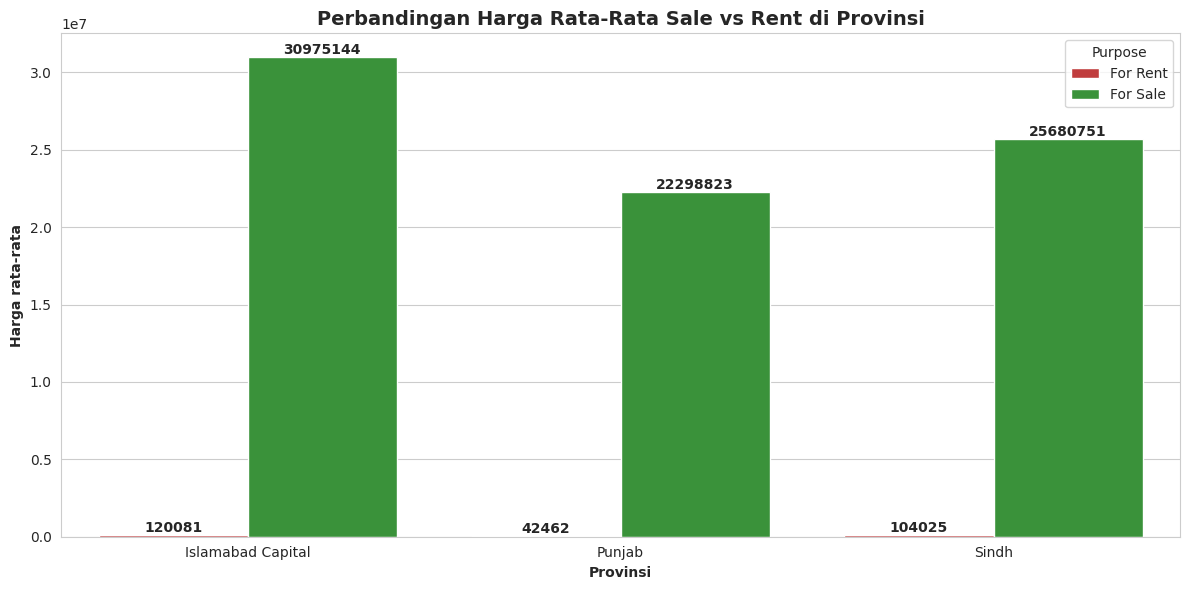

In [25]:
# hitung harga rata-rata berdasarkan kota dan purpose (sell atau rent)
harga_rata_rata_provinsi_purpose = df.groupby(['province_name', 'purpose'])['price'].mean().round(0).reset_index()

harga_rata_rata_provinsi_purpose.columns = ['Provinsi', 'Purpose', 'harga rata-rata']


# Pivot table tampilan
pivot_province_purpose = harga_rata_rata_provinsi_purpose.pivot(index='Provinsi', columns='Purpose', values='harga rata-rata').round(0)

print("Kolom setelah pivot:", pivot_province_purpose.columns.tolist())

pivot_province_purpose = pivot_province_purpose[['For Sale', 'For Rent']] # Urutkan Kolom


# Visualisasi Data
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=harga_rata_rata_provinsi_purpose,
    x="Provinsi",
    y="harga rata-rata",
    hue="Purpose",
    palette={'For Sale': '#2ca02c', 'For Rent': '#d62728'})

plt.title("Perbandingan Harga Rata-Rata Sale vs Rent di Provinsi", fontsize=14, fontweight='bold')

plt.xlabel("Provinsi", fontweight="bold")

plt.ylabel("Harga rata-rata", fontweight="bold")

plt.legend(title='Purpose')

plt.xticks(rotation=0)

for container in ax.containers:

  ax.bar_label(container, fmt='%.0f', fontsize=10, fontweight='bold')

plt.tight_layout()

plt.show()

In [26]:
# Statistik Harga berdasarkan purpose
price_stats = df.groupby('purpose')['price'].agg(['mean', 'median', 'min', 'max']).round(0)

price_stats.columns = ['Rata-Rata', 'Median', 'Minimum', 'Maksimum']

display(price_stats)


# Statistik per provinsi dan purpose
province_purpose_stats = df.groupby(['province_name', 'purpose'])['price'].agg(['mean', 'count']).round(0)

province_purpose_stats['mean_juta'] = (province_purpose_stats['mean'] / 1_000_000).round(0)

display(province_purpose_stats)

,Rata-Rata,Median,Minimum,Maksimum
purpose,,,,
For Rent,94884.0,45000.0,0,12500000
For Sale,24765128.0,13500000.0,0,2000000000


mean  count  mean_juta
province_name     purpose                               
Islamabad Capital For Rent    120081.0  21320        0.0
                  For Sale  30975144.0  16106       31.0
Punjab            For Rent     42462.0  12656        0.0
                  For Sale  22298823.0  57880       22.0
Sindh             For Rent    104025.0  13815        0.0
                  For Sale  25680751.0  46669       26.0

## Correlation

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   property_id    168446 non-null  int64         
 1   location_id    168446 non-null  int64         
 2   page_url       168446 non-null  object        
 3   property_type  168446 non-null  object        
 4   price          168446 non-null  int64         
 5   location       168446 non-null  object        
 6   city           168446 non-null  object        
 7   province_name  168446 non-null  object        
 8   latitude       168446 non-null  float64       
 9   longitude      168446 non-null  float64       
 10  baths          168446 non-null  int64         
 11  purpose        168446 non-null  object        
 12  bedrooms       168446 non-null  int64         
 13  date_added     168446 non-null  datetime64[ns]
 14  area_sqft      168446 non-null  float64       
dtype

In [29]:
# ANALISIS KORELASI ANTAR VARIABEL NUMERIK

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

display(Markdown("# 📈 Analisis Korelasi Antar Variabel"))
display(Markdown("---"))


# 1. PERSIAPAN DATA UNTUK KORELASI
# Identifikasi variabel numerik yang relevan
numeric_cols = ['price', 'bedrooms', 'baths', 'latitude', 'longitude']

# Cek apakah kolom 'area_sqft' sudah ada (hasil konversi dari sebelumnya)
if 'area_sqft' in df.columns:
    numeric_cols.append('area_sqft')
else:
    print("⚠️ Kolom `area_sqft` tidak ditemukan. Analisis tanpa area.")

# Cek apakah ada kolom lain yang numerik
other_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Variabel numerik yang tersedia: {other_numeric}")

# Filter hanya kolom yang ada di dataset
available_cols = [col for col in numeric_cols if col in df.columns]
df_numeric = df[available_cols].copy()

# Handling missing values
print(f"Jumlah data sebelum drop NA: {len(df_numeric)}")
df_numeric = df_numeric.dropna()
print(f"Jumlah data setelah drop NA: {len(df_numeric)}")

# Cek statistik deskriptif
df_numeric.describe().round(2)

# 📈 Analisis Korelasi Antar Variabel

---

Variabel numerik yang tersedia: ['property_id', 'location_id', 'price', 'latitude', 'longitude', 'baths', 'bedrooms', 'area_sqft']
Jumlah data sebelum drop NA: 168446
Jumlah data setelah drop NA: 168446


,price,bedrooms,baths,latitude,longitude,area_sqft
count,1.684460e+05,168446.00,168446.00,168446.00,168446.00,168446.00
mean,1.776576e+07,3.18,2.87,29.86,71.24,3320.73
std,3.531003e+07,1.97,2.46,3.81,3.13,28215.76
min,0.000000e+00,0.00,0.00,11.05,25.91,0.00
25%,1.750000e+05,2.00,0.00,24.95,67.13,1306.80
50%,8.500000e+06,3.00,3.00,31.46,73.06,1932.98
75%,1.950000e+07,4.00,4.00,33.56,73.26,3267.00
max,2.000000e+09,68.00,403.00,73.18,80.16,4356000.00


In [31]:
# 2. CEK OUTLIER (PENTING SEBELUM KORELASI)

# Fungsi untuk mendeteksi outlier dengan IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

outlier_info = []
for col in df_numeric.columns:
    if col not in ['latitude', 'longitude']:  # Geokoordinat punya outlier alami
        n_outliers, lb, ub = detect_outliers_iqr(df_numeric, col)
        outlier_info.append({
            'Variabel': col,
            'Outlier': n_outliers,
            'Persentase': f"{(n_outliers/len(df_numeric))*100:.1f}%",
            'Batas Bawah': f"{lb:.0f}",
            'Batas Atas': f"{ub:.0f}"
        })
        print(f"- {col}: {n_outliers} outlier ({n_outliers/len(df_numeric)*100:.1f}%)")


# Filter outlier untuk price (yang paling penting)
price_outliers = df_numeric[(df_numeric['price'] < 100000) | (df_numeric['price'] > 1_000_000_000)]
df_no_outliers = df_numeric[~df_numeric.index.isin(price_outliers.index)]

- price: 13547 outlier (8.0%)
- bedrooms: 3319 outlier (2.0%)
- baths: 22 outlier (0.0%)
- area_sqft: 9773 outlier (5.8%)


Tabel Koefisien Korelasi:


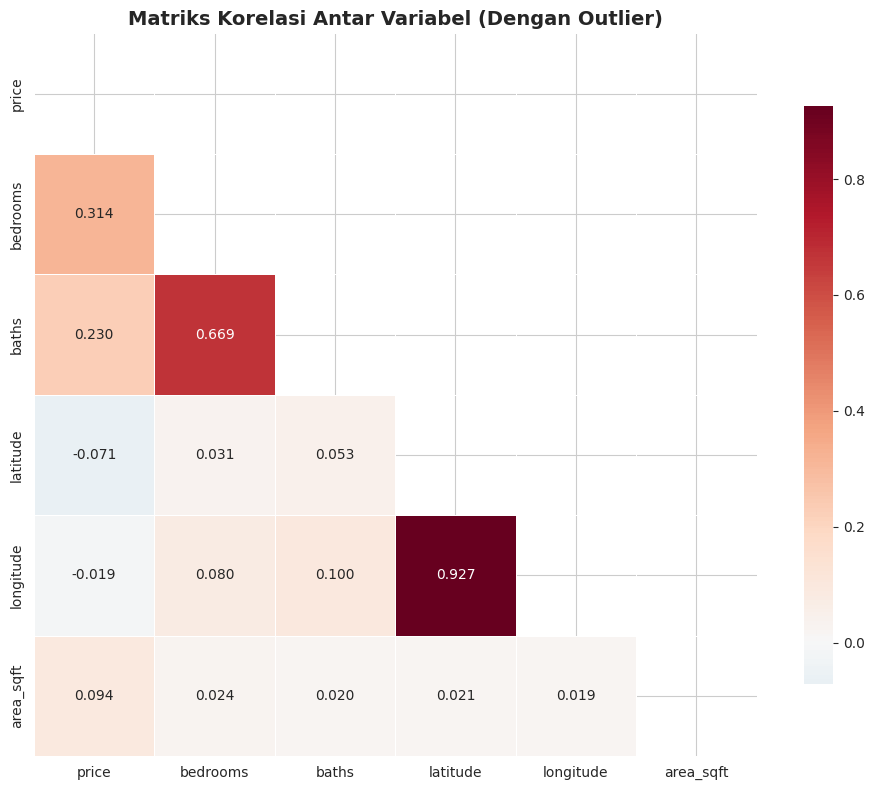

In [32]:
# 3. MATRIKS KORELASI (VERSI 1: DENGAN OUTLIER)

# Hitung matriks korelasi
corr_matrix = df_numeric.corr()

# Tampilkan sebagai tabel
print("Tabel Koefisien Korelasi:")
corr_matrix.round(3)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask untuk segitiga atas
sns.heatmap(corr_matrix,
            annot=True,           # Tampilkan angka
            fmt='.3f',            # Format 3 desimal
            cmap='RdBu_r',        # Warna merah (negatif) - biru (positif)
            center=0,
            square=True,
            linewidths=0.5,
            mask=mask,
            cbar_kws={"shrink": 0.8})
plt.title('Matriks Korelasi Antar Variabel (Dengan Outlier)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Tabel Koefisien Korelasi (Tanpa Outlier):


,price,bedrooms,baths,latitude,longitude,area_sqft
price,1.000,0.290,0.203,-0.031,-0.010,0.124
bedrooms,0.290,1.000,0.639,0.115,0.131,0.030
baths,0.203,0.639,1.000,0.121,0.141,0.023
latitude,-0.031,0.115,0.121,1.000,0.929,0.027
longitude,-0.010,0.131,0.141,0.929,1.000,0.022
area_sqft,0.124,0.030,0.023,0.027,0.022,1.000


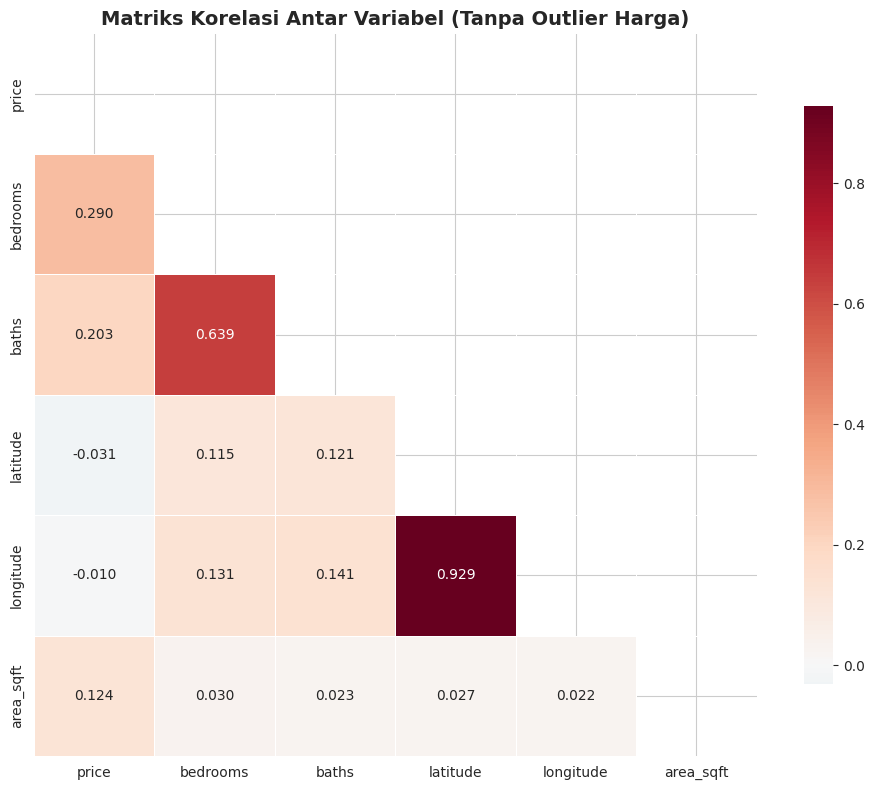

In [33]:
# 4. MATRIKS KORELASI (VERSI 2: TANPA OUTLIER)

if len(df_no_outliers) > 1000:  # Pastikan masih cukup data
    corr_matrix_clean = df_no_outliers.corr()

    print("Tabel Koefisien Korelasi (Tanpa Outlier):")
    display(corr_matrix_clean.round(3))

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_matrix_clean,
                annot=True,
                fmt='.3f',
                cmap='RdBu_r',
                center=0,
                square=True,
                linewidths=0.5,
                mask=mask,
                cbar_kws={"shrink": 0.8})
    plt.title('Matriks Korelasi Antar Variabel (Tanpa Outlier Harga)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Data terlalu sedikit setelah filter outlier.")

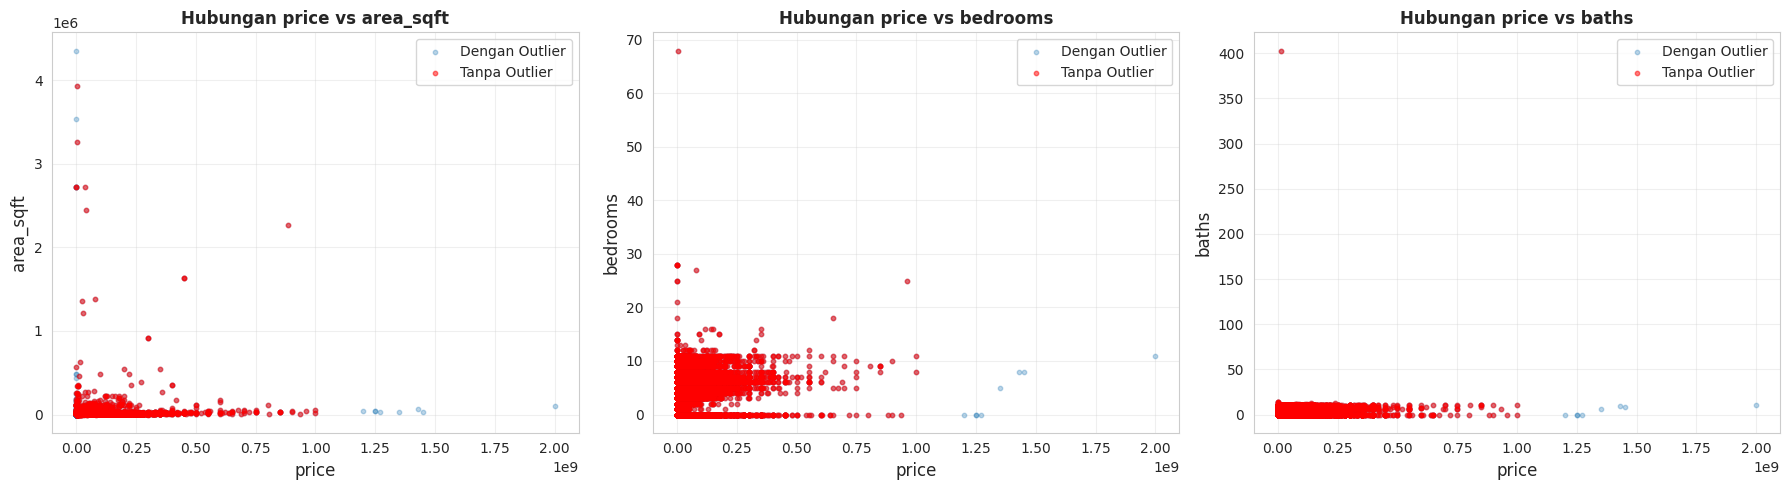

In [34]:
# 5. VISUALISASI SCATTER PLOT (HUBUNGAN PASANGAN VARIABEL)

# Pilih pasangan variabel yang paling relevan
pairs = []
if 'area_sqft' in df_numeric.columns:
    pairs = [('price', 'area_sqft'), ('price', 'bedrooms'), ('price', 'baths')]
else:
    pairs = [('price', 'bedrooms'), ('price', 'baths')]

fig, axes = plt.subplots(1, len(pairs), figsize=(6*len(pairs), 5))
if len(pairs) == 1:
    axes = [axes]

for ax, (x, y) in zip(axes, pairs):
    # Scatter plot dengan outlier dibedakan
    ax.scatter(df_numeric[x], df_numeric[y], alpha=0.3, s=10, label='Dengan Outlier')
    if len(df_no_outliers) > 1000:
        ax.scatter(df_no_outliers[x], df_no_outliers[y], alpha=0.5, s=10, c='red', label='Tanpa Outlier')

    ax.set_xlabel(x, fontsize=12)
    ax.set_ylabel(y, fontsize=12)
    ax.set_title(f'Hubungan {x} vs {y}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# 6. KORELASI PER KATEGORI (Berdasarkan Purpose)

if 'purpose' in df.columns and len(df_no_outliers) > 1000:
  df_with_purpose = df_no_outliers.copy()
  df_with_purpose['purpose'] = df.loc[df_with_purpose.index, 'purpose']

  for purpose_val in ['Sale', 'Rent']:
    df_purpose = df_with_purpose[df_with_purpose['purpose'] == purpose_val]
    if len(df_purpose) > 100:
      print(f"Korelasi untuk Properti {purpose_val}")
      corr_purpose = df_purpose[available_cols].corr()
      corr_purpose.round(3)

      # Heatmap kecil
      fig, ax = plt.subplots(figsize=(8, 6))
      sns.heatmap(corr_purpose, annot=True, fmt='.3f', cmap='RdBu_r',
                  center=0, square=True, linewidths=0.5, ax=ax)
      ax.set_title(f'Matriks Korelasi - {purpose_val}', fontsize=12, fontweight='bold')
      plt.tight_layout()
      plt.show()

In [41]:
# 7. KORELASI PER KOTA (BONUS: Kota Terbesar)

if 'city' in df.columns and len(df_no_outliers) > 1000:
  top_cities = df['city'].value_counts().head(5).index
  df_with_city = df_no_outliers.copy()
  df_with_city['city'] = df.loc[df_with_city.index, 'city']

  for city in top_cities:
    df_city = df_with_city[df_with_city['city'] == city]
    if len(df_city) > 50 and len(available_cols) >= 2:
      print(f"Korelasi untuk Kota {city} (n={len(df_city)})")
      corr_city = df_city[available_cols].corr()
      display(corr_city.round(3))

Korelasi untuk Kota Karachi (n=50763)


,price,bedrooms,baths,latitude,longitude,area_sqft
price,1.000,0.363,0.263,-0.100,-0.093,0.100
bedrooms,0.363,1.000,0.686,-0.070,-0.022,0.056
baths,0.263,0.686,1.000,-0.042,0.018,0.046
latitude,-0.100,-0.070,-0.042,1.000,0.080,-0.018
longitude,-0.093,-0.022,0.018,0.080,1.000,-0.012
area_sqft,0.100,0.056,0.046,-0.018,-0.012,1.000


Korelasi untuk Kota Lahore (n=41386)


,price,bedrooms,baths,latitude,longitude,area_sqft
price,1.000,0.322,0.241,0.009,0.156,0.194
bedrooms,0.322,1.000,0.614,-0.047,0.030,0.019
baths,0.241,0.614,1.000,-0.156,0.036,0.021
latitude,0.009,-0.047,-0.156,1.000,0.370,-0.001
longitude,0.156,0.030,0.036,0.370,1.000,0.024
area_sqft,0.194,0.019,0.021,-0.001,0.024,1.000


Korelasi untuk Kota Islamabad (n=22253)


,price,bedrooms,baths,latitude,longitude,area_sqft
price,1.000,0.202,0.161,0.018,-0.021,0.111
bedrooms,0.202,1.000,0.775,0.014,-0.072,0.012
baths,0.161,0.775,1.000,0.006,-0.038,0.004
latitude,0.018,0.014,0.006,1.000,0.125,0.006
longitude,-0.021,-0.072,-0.038,0.125,1.000,0.002
area_sqft,0.111,0.012,0.004,0.006,0.002,1.000


Korelasi untuk Kota Rawalpindi (n=12355)


,price,bedrooms,baths,latitude,longitude,area_sqft
price,1.000,0.282,0.155,-0.002,0.026,0.115
bedrooms,0.282,1.000,0.408,-0.015,0.031,0.034
baths,0.155,0.408,1.000,-0.014,0.017,0.021
latitude,-0.002,-0.015,-0.014,1.000,-0.964,-0.012
longitude,0.026,0.031,0.017,-0.964,1.000,-0.006
area_sqft,0.115,0.034,0.021,-0.012,-0.006,1.000


Korelasi untuk Kota Faisalabad (n=4665)


,price,bedrooms,baths,latitude,longitude,area_sqft
price,1.000,0.094,0.070,0.063,0.013,0.502
bedrooms,0.094,1.000,0.777,0.096,-0.001,0.091
baths,0.070,0.777,1.000,0.044,-0.006,0.092
latitude,0.063,0.096,0.044,1.000,0.034,0.044
longitude,0.013,-0.001,-0.006,0.034,1.000,0.008
area_sqft,0.502,0.091,0.092,0.044,0.008,1.000


In [42]:
# 8. INTERPRETASI HASIL KORELASI
display(Markdown("---"))
display(Markdown("## 📝 Interpretasi Koefisien Korelasi"))

display(Markdown("""
**Pedoman interpretasi nilai korelasi (r):**

| Nilai r | Interpretasi |
|---------|--------------|
| 0.90 - 1.00 | Korelasi sangat kuat (positif) |
| 0.70 - 0.89 | Korelasi kuat (positif) |
| 0.50 - 0.69 | Korelasi sedang (positif) |
| 0.30 - 0.49 | Korelasi lemah (positif) |
| 0.00 - 0.29 | Korelasi sangat lemah / tidak berkorelasi |
| (-0.30) - (-0.01) | Korelasi negatif lemah |
| (-0.50) - (-0.31) | Korelasi negatif sedang |
| (-0.70) - (-0.51) | Korelasi negatif kuat |
| (-1.00) - (-0.71) | Korelasi negatif sangat kuat |

**Yang perlu diperhatikan dari hasil di atas:**

1. **Korelasi price vs bedrooms** → seberapa kuat hubungan jumlah kamar dengan harga
2. **Korelasi price vs baths** → apakah kamar mandi lebih berpengaruh dari kamar tidur
3. **Korelasi price vs area_sqft** (jika ada) → apakah luas tanah/ bangunan sangat menentukan harga
4. **Perbedaan korelasi antara Sale vs Rent** → apakah faktor yang mempengaruhi harga berbeda
5. **Perbedaan antar kota** → apakah di Karachi, hubungan bedrooms dan harga berbeda dengan Lahore
"""))

# ============================================
# 9. INSIGHT DAN REKOMENDASI
# ============================================
display(Markdown("## 💡 Insight & Rekomendasi Berdasarkan Korelasi"))

# Hitung insight otomatis jika memungkinkan
if 'price' in corr_matrix.columns:
    # Cari variabel dengan korelasi tertinggi terhadap price
    price_corr = corr_matrix['price'].drop('price').sort_values(ascending=False)
    if len(price_corr) > 0:
        top_corr = price_corr.index[0]
        top_value = price_corr.values[0]
        display(Markdown(f"**Variabel dengan korelasi tertinggi terhadap price:** `{top_corr}` (r = {top_value:.3f})"))

        if top_value > 0.7:
            display(Markdown(f"✅ `{top_corr}` memiliki hubungan **kuat** dengan harga properti."))
        elif top_value > 0.5:
            display(Markdown(f"📈 `{top_corr}` memiliki hubungan **sedang** dengan harga properti."))
        elif top_value > 0.3:
            display(Markdown(f"⚠️ `{top_corr}` memiliki hubungan **lemah** dengan harga properti."))
        else:
            display(Markdown(f"🔍 `{top_corr}` hampir **tidak berkorelasi** dengan harga properti."))

display(Markdown("---"))
display(Markdown("**✅ Selesai – Analisis korelasi selesai dijalankan.**"))

---

## 📝 Interpretasi Koefisien Korelasi


**Pedoman interpretasi nilai korelasi (r):**

| Nilai r | Interpretasi |
|---------|--------------|
| 0.90 - 1.00 | Korelasi sangat kuat (positif) |
| 0.70 - 0.89 | Korelasi kuat (positif) |
| 0.50 - 0.69 | Korelasi sedang (positif) |
| 0.30 - 0.49 | Korelasi lemah (positif) |
| 0.00 - 0.29 | Korelasi sangat lemah / tidak berkorelasi |
| (-0.30) - (-0.01) | Korelasi negatif lemah |
| (-0.50) - (-0.31) | Korelasi negatif sedang |
| (-0.70) - (-0.51) | Korelasi negatif kuat |
| (-1.00) - (-0.71) | Korelasi negatif sangat kuat |

**Yang perlu diperhatikan dari hasil di atas:**

1. **Korelasi price vs bedrooms** → seberapa kuat hubungan jumlah kamar dengan harga
2. **Korelasi price vs baths** → apakah kamar mandi lebih berpengaruh dari kamar tidur
3. **Korelasi price vs area_sqft** (jika ada) → apakah luas tanah/ bangunan sangat menentukan harga
4. **Perbedaan korelasi antara Sale vs Rent** → apakah faktor yang mempengaruhi harga berbeda
5. **Perbedaan antar kota** → apakah di Karachi, hubungan bedrooms dan harga berbeda dengan Lahore


## 💡 Insight & Rekomendasi Berdasarkan Korelasi

**Variabel dengan korelasi tertinggi terhadap price:** `bedrooms` (r = 0.314)

⚠️ `bedrooms` memiliki hubungan **lemah** dengan harga properti.

---

**✅ Selesai – Analisis korelasi selesai dijalankan.**

## Geospatial

# 🗺️ Analisis Geospatial Properti

---

## 1. Persiapan Data Koordinat

**Jumlah data dengan koordinat valid:** 168,436 properti

**Persentase dari total data:** 100.0%

## 2. Peta Sebaran Properti (Scatter Plot)

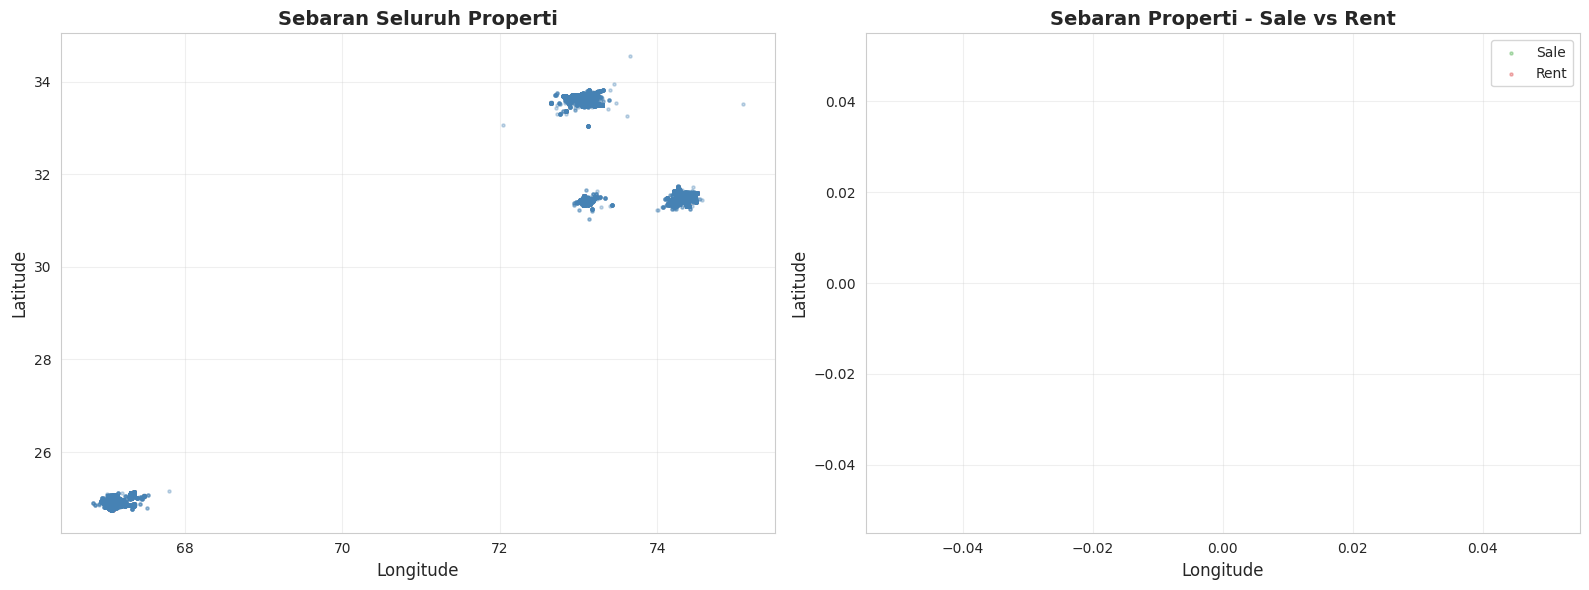

## 3. Peta Harga Rata-Rata per Grid

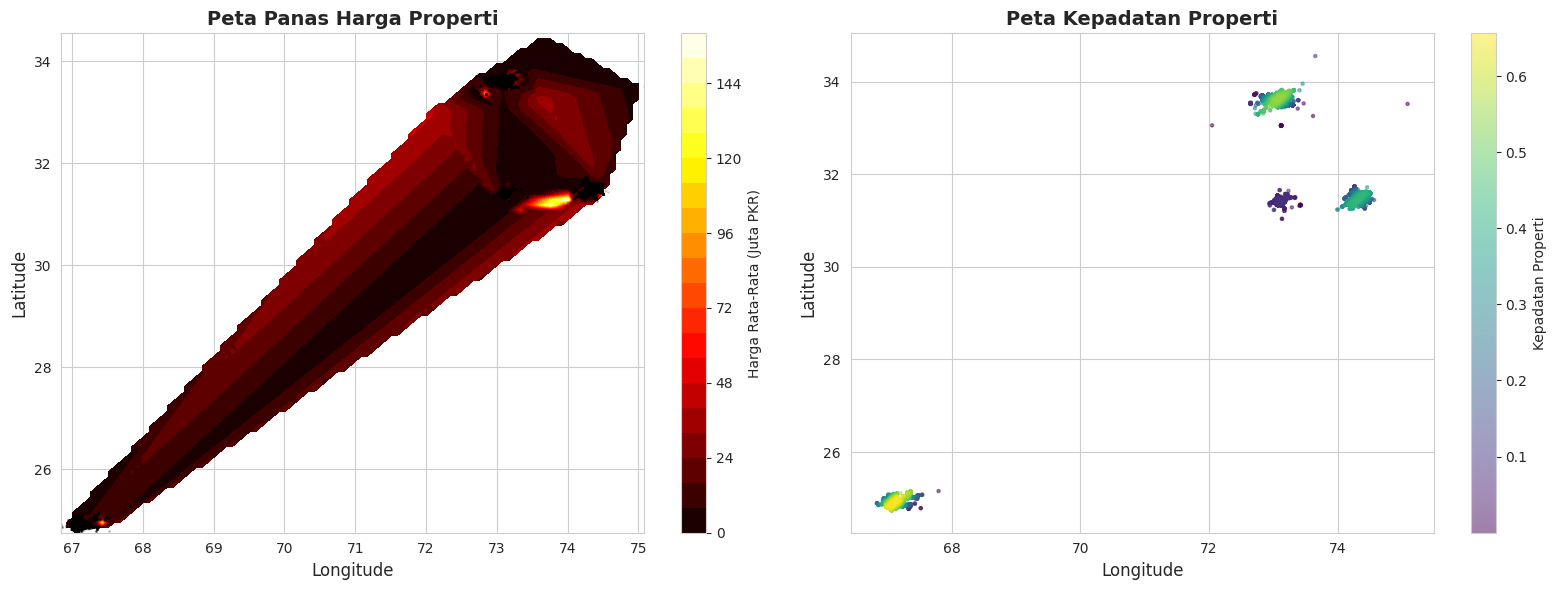

## 4. Statistik Geospatial per Kota

KeyError: 'count'

In [ ]:
# ============================================
# ANALISIS GEOSPATIAL (PETA PERSEBARAN PROPERTI)
# ============================================

from IPython.display import Markdown, display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

display(Markdown("# 🗺️ Analisis Geospatial Properti"))
display(Markdown("---"))

# ============================================
# 1. PERSIAPAN DATA GEOSPATIAL
# ============================================
display(Markdown("## 1. Persiapan Data Koordinat"))

# Cek ketersediaan kolom latitude dan longitude
if 'latitude' not in df.columns or 'longitude' not in df.columns:
    display(Markdown("❌ **Error:** Kolom latitude dan/atau longitude tidak ditemukan dalam dataset!"))
else:
    # Filter data yang memiliki koordinat valid
    df_geo = df.dropna(subset=['latitude', 'longitude']).copy()

    # Filter koordinat dalam batas geografis Pakistan (perkiraan)
    # Pakistan: Latitude ~24°N - 37°N, Longitude ~61°E - 77°E
    df_geo = df_geo[
        (df_geo['latitude'].between(24, 37)) &
        (df_geo['longitude'].between(61, 77))
    ]

    display(Markdown(f"**Jumlah data dengan koordinat valid:** {len(df_geo):,} properti"))
    display(Markdown(f"**Persentase dari total data:** {(len(df_geo)/len(df)*100):.1f}%"))

# ============================================
# 2. SCATTER PLOT PETA SEDERHANA (MATPLOTLIB)
# ============================================
display(Markdown("## 2. Peta Sebaran Properti (Scatter Plot)"))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Sebaran dasar
ax1 = axes[0]
scatter = ax1.scatter(df_geo['longitude'], df_geo['latitude'],
                      c='steelblue', alpha=0.3, s=5)
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.set_title('Sebaran Seluruh Properti', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot 2: Berdasarkan Purpose (Sale vs Rent)
ax2 = axes[1]
for purpose_type, color in [('Sale', '#2ca02c'), ('Rent', '#d62728')]:
    subset = df_geo[df_geo['purpose'] == purpose_type]
    ax2.scatter(subset['longitude'], subset['latitude'],
                c=color, alpha=0.3, s=5, label=purpose_type)
ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)
ax2.set_title('Sebaran Properti - Sale vs Rent', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 3. PETA HARGA (HEATMAP DENGAN BINNING)
# ============================================
display(Markdown("## 3. Peta Harga Rata-Rata per Grid"))

# Buat grid berdasarkan longitude dan latitude
df_geo['price_juta'] = df_geo['price'] / 1_000_000

# Bagi area menjadi grid 50x50
lon_bins = np.linspace(df_geo['longitude'].min(), df_geo['longitude'].max(), 50)
lat_bins = np.linspace(df_geo['latitude'].min(), df_geo['latitude'].max(), 50)

# Hitung rata-rata harga per grid
df_geo['lon_bin'] = pd.cut(df_geo['longitude'], lon_bins, labels=False)
df_geo['lat_bin'] = pd.cut(df_geo['latitude'], lat_bins, labels=False)

grid_price = df_geo.groupby(['lon_bin', 'lat_bin'])['price_juta'].mean().reset_index()
grid_count = df_geo.groupby(['lon_bin', 'lat_bin']).size().reset_index(name='count')

# Plot heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap harga rata-rata
from scipy.interpolate import griddata

# Interpolasi untuk smooth heatmap
xi = np.linspace(df_geo['longitude'].min(), df_geo['longitude'].max(), 100)
yi = np.linspace(df_geo['latitude'].min(), df_geo['latitude'].max(), 100)
xi_grid, yi_grid = np.meshgrid(xi, yi)

# Interpolasi harga
zi = griddata((df_geo['longitude'], df_geo['latitude']), df_geo['price_juta'],
              (xi_grid, yi_grid), method='linear')

ax1 = axes[0]
contour = ax1.contourf(xi_grid, yi_grid, zi, levels=20, cmap='hot')
plt.colorbar(contour, ax=ax1, label='Harga Rata-Rata (Juta PKR)')
ax1.scatter(df_geo['longitude'], df_geo['latitude'], alpha=0.1, s=1, c='black')
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.set_title('Peta Panas Harga Properti', fontsize=14, fontweight='bold')

# Heatmap kepadatan properti
ax2 = axes[1]
from scipy.stats import gaussian_kde

xy = np.vstack([df_geo['longitude'], df_geo['latitude']])
z = gaussian_kde(xy)(xy)

idx = z.argsort()
x_sorted = df_geo['longitude'].iloc[idx]
y_sorted = df_geo['latitude'].iloc[idx]
z_sorted = z[idx]

scatter = ax2.scatter(x_sorted, y_sorted, c=z_sorted, s=5, alpha=0.5, cmap='viridis')
plt.colorbar(scatter, ax=ax2, label='Kepadatan Properti')
ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)
ax2.set_title('Peta Kepadatan Properti', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# 4. ANALISIS PER KOTA (STATISTIK GEOSPATIAL)
# ============================================
display(Markdown("## 4. Statistik Geospatial per Kota"))

# Hitung pusat koordinat (centroid) setiap kota
city_geo = df_geo.groupby('city').agg({
    'latitude': 'mean',
    'longitude': 'mean',
    'price': 'mean',
    'price': 'count'
}).rename(columns={'price': 'count', 'price': 'avg_price'})

city_geo['avg_price_juta'] = (city_geo['avg_price'] / 1_000_000).round(0)
city_geo = city_geo[city_geo['count'] > 10]  # Hanya kota dengan minimal 10 properti

display(Markdown("**Pusat Koordinat & Harga Rata-Rata per Kota:**"))
display(city_geo[['latitude', 'longitude', 'count', 'avg_price_juta']].head(20))

# Plot kota pada peta dengan ukuran berdasarkan jumlah properti
fig, ax = plt.subplots(figsize=(14, 10))

# Plot semua properti sebagai latar (alpha kecil)
ax.scatter(df_geo['longitude'], df_geo['latitude'], alpha=0.05, s=2, c='gray')

# Plot centroid kota
scatter = ax.scatter(city_geo['longitude'], city_geo['latitude'],
                     s=city_geo['count']/100,  # Ukuran berdasarkan jumlah properti
                     c=city_geo['avg_price_juta'],  # Warna berdasarkan harga
                     cmap='RdYlGn_r', edgecolors='black', linewidth=0.5, alpha=0.8)

# Tambahkan label kota (hanya untuk yang signifikan)
for idx, row in city_geo.iterrows():
    if row['count'] > 500:  # Label hanya untuk kota besar
        ax.annotate(idx, (row['longitude'], row['latitude']),
                   fontsize=9, ha='center', va='bottom', weight='bold',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))

plt.colorbar(scatter, ax=ax, label='Harga Rata-Rata (Juta PKR)')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Peta Properti per Kota (Ukuran = Jumlah Properti, Warna = Harga Rata-Rata)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 5. ANALISIS HARDCODE UNTUK 5 KOTA BESAR
# ============================================
display(Markdown("## 5. Analisis Detail untuk 5 Kota Besar"))

top_cities = df_geo['city'].value_counts().head(5).index
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, city in enumerate(top_cities):
    df_city = df_geo[df_geo['city'] == city]

    ax = axes[idx]
    scatter = ax.scatter(df_city['longitude'], df_city['latitude'],
                         c=df_city['price']/1_000_000, s=8, alpha=0.6, cmap='plasma')
    ax.set_title(f'{city} (n={len(df_city):,} properti)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.colorbar(scatter, ax=ax, label='Harga (Juta PKR)')

# Hapus subplot ke-6 jika tidak terpakai
if len(top_cities) < 6:
    fig.delaxes(axes[5])

plt.suptitle('Sebaran Harga Properti per Kota', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 6. ANALISIS KORELASI GEOSPATIAL
# ============================================
display(Markdown("## 6. Korelasi antara Lokasi dan Harga"))

# Apakah harga berkorelasi dengan latitude/longitude?
corr_lat_price = df_geo['latitude'].corr(df_geo['price'])
corr_lon_price = df_geo['longitude'].corr(df_geo['price'])

display(Markdown(f"**Korelasi Latitude vs Price:** {corr_lat_price:.4f}"))
display(Markdown(f"**Korelasi Longitude vs Price:** {corr_lon_price:.4f}"))

if abs(corr_lat_price) > 0.3:
    display(Markdown(f"✅ Ada korelasi {'positif' if corr_lat_price > 0 else 'negatif'} sedang antara latitude dan harga."))
else:
    display(Markdown("⚠️ Korelasi latitude dengan harga sangat lemah."))

# Analisis kuadran (area mahal vs murah)
price_median = df_geo['price'].median()
lat_median = df_geo['latitude'].median()
lon_median = df_geo['longitude'].median()

df_geo['price_category'] = np.where(df_geo['price'] > price_median, 'Mahal', 'Murah')
df_geo['lat_category'] = np.where(df_geo['latitude'] > lat_median, 'Utara', 'Selatan')
df_geo['lon_category'] = np.where(df_geo['longitude'] > lon_median, 'Timur', 'Barat')

# Tabel kontingensi
display(Markdown("**Sebaran Properti Mahal vs Murah Berdasarkan Arah Mata Angin:**"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Utara vs Selatan
lat_pivot = pd.crosstab(df_geo['price_category'], df_geo['lat_category'], normalize='columns') * 100
lat_pivot.T.plot(kind='bar', ax=axes[0], color=['#ff9999', '#66b3ff'])
axes[0].set_title('Persentase Harga: Utara vs Selatan', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Wilayah')
axes[0].set_ylabel('Persentase (%)')
axes[0].legend(title='Harga')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2: Timur vs Barat
lon_pivot = pd.crosstab(df_geo['price_category'], df_geo['lon_category'], normalize='columns') * 100
lon_pivot.T.plot(kind='bar', ax=axes[1], color=['#ff9999', '#66b3ff'])
axes[1].set_title('Persentase Harga: Timur vs Barat', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Wilayah')
axes[1].set_ylabel('Persentase (%)')
axes[1].legend(title='Harga')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# ============================================
# 7. PETA CLUSTER BERDASARKAN HARGA (KUANTIL)
# ============================================
display(Markdown("## 7. Klasterisasi Properti Berdasarkan Harga"))

# Bagi properti menjadi 4 kelompok harga (kuartil)
df_geo['price_cluster'] = pd.qcut(df_geo['price'], q=4, labels=['Murah', 'Menengah Bawah', 'Menengah Atas', 'Mahal'])

fig, ax = plt.subplots(figsize=(14, 10))

colors = {'Murah': '#2ecc71', 'Menengah Bawah': '#f1c40f',
          'Menengah Atas': '#e67e22', 'Mahal': '#e74c3c'}

for cluster, color in colors.items():
    subset = df_geo[df_geo['price_cluster'] == cluster]
    ax.scatter(subset['longitude'], subset['latitude'],
               c=color, alpha=0.4, s=8, label=cluster)

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Klaster Properti Berdasarkan Harga (Kuartil)', fontsize=14, fontweight='bold')
ax.legend(title='Kelompok Harga', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 8. INSIGHT GEOSPATIAL
# ============================================
display(Markdown("---"))
display(Markdown("## 📝 Insight Geospatial"))

# Hitung beberapa insight otomatis
display(Markdown("### 🔍 Temuan Utama:"))

# Kota termahal berdasarkan koordinat
if len(city_geo) > 0:
    most_expensive_city = city_geo.nlargest(1, 'avg_price')
    display(Markdown(f"- **Kota termahal:** {most_expensive_city.index[0]} dengan harga rata-rata {most_expensive_city['avg_price_juta'].values[0]:,} Juta PKR"))

    cheapest_city = city_geo.nsmallest(1, 'avg_price')
    display(Markdown(f"- **Kota termurah:** {cheapest_city.index[0]} dengan harga rata-rata {cheapest_city['avg_price_juta'].values[0]:,} Juta PKR"))

# Wilayah dengan properti terbanyak
if len(top_cities) > 0:
    display(Markdown(f"- **Kota dengan properti terbanyak:** {top_cities[0]} ({len(df_geo[df_geo['city'] == top_cities[0]]):,} properti)"))

# Pola geografis
if abs(corr_lat_price) > 0.2:
    direction = "utara" if corr_lat_price > 0 else "selatan"
    display(Markdown(f"- **Pola geografis:** Harga cenderung lebih tinggi di wilayah {direction}"))

# Distribusi Sale vs Rent berdasarkan geografi
display(Markdown("### 📊 Distribusi Geografis Sale vs Rent:"))

# Hitung proporsi Sale vs Rent per wilayah (berdasarkan kuadran)
for quadrant, lon_label, lat_label in [('Barat Laut', 'Barat', 'Utara'),
                                        ('Timur Laut', 'Timur', 'Utara'),
                                        ('Barat Daya', 'Barat', 'Selatan'),
                                        ('Timur Daya', 'Timur', 'Selatan')]:
    subset = df_geo[(df_geo['lon_category'] == lon_label) & (df_geo['lat_category'] == lat_label)]
    if len(subset) > 100:
        sale_pct = (subset['purpose'] == 'Sale').mean() * 100
        display(Markdown(f"- **{quadrant}:** {sale_pct:.1f}% Sale, {100-sale_pct:.1f}% Rent"))

# ============================================
# 9. REKOMENDASI
# ============================================
display(Markdown("---"))
display(Markdown("## 💡 Rekomendasi Berdasarkan Analisis Geospatial"))

display(Markdown("""
**Berdasarkan analisis peta di atas, berikut rekomendasi yang dapat diambil:**

1. **Target Area Ekspansi:**
   - Identifikasi area dengan kepadatan properti tinggi namun harga masih terjangkau
   - Perhatikan area kosong (blank spot) di peta panas sebagai potensi pasar baru

2. **Strategi Harga Berbasis Lokasi:**
   - Gunakan peta harga untuk menentukan harga kompetitif per wilayah
   - Area dengan gradien harga curam → potensi arbitrase geografis

3. **Segmentasi Pasar:**
   - Wilayah dengan dominasi "Sale" → fokus pada agen jual beli
   - Wilayah dengan dominasi "Rent" → fokus pada manajemen properti sewa

4. **Validasi Lapangan:**
   - Gunakan koordinat untuk verifikasi apakah properti benar-benar berada di lokasi yang diklaim
   - Deteksi anomali (misal properti mahal tapi di lokasi tidak strategis)

5. **Pengembangan Model Prediksi:**
   - Koordinat geografis dapat menjadi fitur penting dalam model prediksi harga
   - Gunakan jarak ke pusat kota atau fasilitas umum sebagai fitur turunan
"""))

display(Markdown("---"))
display(Markdown("**✅ Selesai – Analisis Geospatial selesai dijalankan.**"))

# Data Preprocessing

# Feature Engineering

# Data Splitting

# Modeling

# Model Evaluation

# Residual Analysis

# Feature Importance Interpretation

# Comparison with SKLEARN

# Advanced Section